In [1]:
# Cell 1: Setup
import sys
sys.path.append('../src')
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


In [2]:
# Cell 2: Load MAESTRO data
from training.data_loader import get_data_loaders

BATCH_SIZE = 32
train_loader, val_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE)

Loaded 8830 segments from ../data/train_test_split/train.npy
Shape: (8830, 128, 49), Memory: 211.3 MB
Loaded 3204 segments from ../data/train_test_split/val.npy
Shape: (3204, 128, 49), Memory: 76.7 MB
Loaded 3961 segments from ../data/train_test_split/test.npy
Shape: (3961, 128, 49), Memory: 94.8 MB

Train batches: 276, Val batches: 101, Test batches: 124


In [3]:
# Cell 3: Create VAE model
from models.vae import VAE

model = VAE(
    input_dim=49,
    hidden_dim=128,  # Reduced capacity
    latent_dim=16,
    seq_len=128,
    num_layers=1
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Latent dimension: {model.latent_dim}")

Total parameters: 293,841
Latent dimension: 16


In [4]:
# Test KL calculation with random values
test_mu = torch.randn(4, 32) * 0.5
test_log_var = torch.randn(4, 32) * 0.5
kl_value = model.kl_divergence(test_mu, test_log_var)
print(f"Test KL with random values: {kl_value.item():.4f}")
# Should be around 5-20, not 0.0001

Test KL with random values: 5.9631


In [5]:
# Cell 4: Train VAE
from training.train_vae import VAETrainer

trainer = VAETrainer(model, beta=5000, device='cpu', learning_rate=0.001)
train_losses, val_losses = trainer.train(
    train_loader, val_loader,
    epochs=50,
    save_path='../outputs/models/vae_maestro.pth'
)


Training VAE on MAESTRO (beta=5000)
Device: cpu
Epochs: 50
Learning rate: 0.001



Epoch 1/50
  Train - Recon: 0.049084, KL: 0.018191, Total: 91.005134
  Val   - Recon: 0.033308, KL: 0.000384, Total: 1.954132
  -> Saved best model


Epoch 2/50
  Train - Recon: 0.035394, KL: 0.000666, Total: 3.363002
  Val   - Recon: 0.033301, KL: 0.000103, Total: 0.548536
  -> Saved best model


Epoch 3/50
  Train - Recon: 0.035386, KL: 0.000413, Total: 2.100433
  Val   - Recon: 0.033339, KL: 0.000034, Total: 0.203870
  -> Saved best model


Epoch 4/50
  Train - Recon: 0.035379, KL: 0.000297, Total: 1.519569
  Val   - Recon: 0.033295, KL: 0.000028, Total: 0.174792
  -> Saved best model


...

Epoch 37/50
  Train - Recon: 0.035350, KL: 0.000000, Total: 0.035355
  Val   - Recon: 0.033271, KL: 0.000000, Total: 0.033271


Epoch 38/50
  Train - Recon: 0.035348, KL: 0.000000, Total: 0.035378
  Val   - Recon: 0.033282, KL: 0.000000, Total: 0.033318


Epoch 39/50
  Train - Recon: 0.035348, KL: 0.000000, Total: 0.035358
  Val   - Recon: 0.033280, KL: 0.000000, Total: 0.033280


Epoch 40/50
  Train - Recon: 0.035348, KL: 0.000000, Total: 0.035348
  Val   - Recon: 0.033327, KL: 0.000000, Total: 0.033351


KeyboardInterrupt: 

In [ ]:
# Cell 5: Generate 8 samples for Task 2 (VAE)
from generation.midi_export import numpy_to_midi

# Load the trained VAE model
checkpoint = torch.load('../outputs/models/vae_maestro.pth', map_location='cpu')

# Get latent dimension from saved model
latent_dim = checkpoint['model_state_dict']['decoder.fc_hidden.weight'].shape[1]
print(f"Loaded VAE model from epoch {checkpoint['epoch']}")
print(f"Validation loss: {checkpoint['val_loss']:.6f}")
print(f"Latent dimension: {latent_dim}")

# Recreate model with exact architecture
from models.vae import VAE

model = VAE(
    input_dim=49,
    hidden_dim=128,
    latent_dim=latent_dim,
    seq_len=128,
    num_layers=1
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully")

# Generate 8 samples
output_dir = '../outputs/generated_midis/task2_vae/'
os.makedirs(output_dir, exist_ok=True)

print(f"\nGenerating 8 samples by sampling z ~ N(0, I)...")
for i in range(8):
    with torch.no_grad():
        # Sample random latent vector from standard normal distribution
        z = torch.randn(1, latent_dim)
        
        # Decode to piano roll
        generated = model.decoder(z)
        generated = generated.squeeze().cpu().numpy()
        
        # Clip values to [0, 1]
        generated = np.clip(generated, 0, 1)
        
        # Save as MIDI
        output_path = os.path.join(output_dir, f'task2_sample_{i+1}.mid')
        numpy_to_midi(generated, output_path, tempo=120, velocity_scale=100)
        
        # Also save as numpy for backup
        np.save(os.path.join(output_dir, f'task2_sample_{i+1}.npy'), generated)
        
        # Print statistics
        density = generated.mean() * 100
        max_val = generated.max()
        print(f"Sample {i+1}: density={density:.1f}%, max={max_val:.3f}")

print(f"\n8 samples saved to {output_dir}")

Loaded VAE model from epoch 36
Validation loss: 0.033262
Latent dimension: 16
Model loaded successfully

Generating 8 samples by sampling z ~ N(0, I)...
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_1.mid
Sample 1: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_2.mid
Sample 2: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_3.mid
Sample 3: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_4.mid
Sample 4: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_5.mid
Sample 5: density=7.0%, max=0.107
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_6.mid
Sample 6: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_7.mid
Sample 7: density=7.0%, max=0.106
MIDI saved: ../outputs/generated_midis/task2_vae/task2_sample_8.mid
Sample 8: density=7.0%, max=0.106

8 samples saved to ../outputs/

Loaded sample 1: shape (128, 49)
Loaded sample 2: shape (128, 49)
Loaded sample 3: shape (128, 49)
Loaded sample 4: shape (128, 49)
Loaded sample 5: shape (128, 49)
Loaded sample 6: shape (128, 49)
Loaded sample 7: shape (128, 49)
Loaded sample 8: shape (128, 49)

Loaded 8 generated samples

EVALUATION METRICS - Task 2: Variational Autoencoder
Rhythm Diversity: 0.0526 (+- 0.0214)
Repetition Ratio: 0.8984 (+- 0.0303)
Pitch Histogram Similarity: 0.6308 (+- 0.1629)
Loaded human feedback from ../data/human_feedback/Task_2/feedback.xlsx
  Participants: 10
  Samples: 8
  Score range: 3.4 - 4.2

HUMAN LISTENING SCORE - Task 2: Variational Autoencoder
Participants: 10
Samples evaluated: 8
Overall Score: 3.87 / 5.00 (+- 0.21)
Score Range: 3.4 - 4.2

Per-Sample Scores:
  Sample 1: 3.69
  Sample 2: 3.79
  Sample 3: 4.09
  Sample 4: 3.60
  Sample 5: 4.02
  Sample 6: 4.07
  Sample 7: 3.68
  Sample 8: 3.98


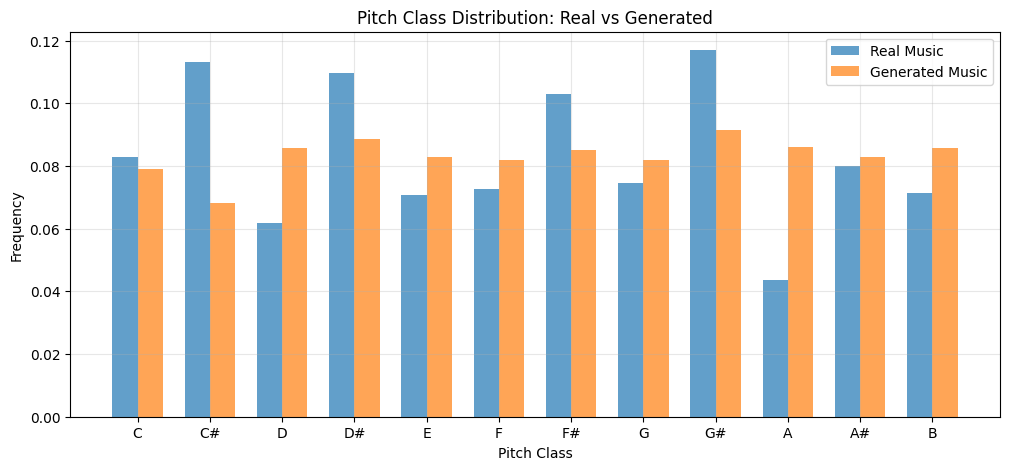

Pitch Histogram Similarity: 0.6308
Plot saved to ../outputs/plots/task_2_pitch_histogram_comparison.png


In [ ]:
# Cell 6: Evaluate Task 2 Model Metrics
import sys
sys.path.append('../src')
import numpy as np
import os
import pretty_midi
import matplotlib.pyplot as plt
from evaluation.pitch_histogram import compute_pitch_histogram
from evaluation.metrics import compute_all_metrics, print_metrics
from evaluation.human_score import load_human_scores, compute_human_score, print_human_score

def midi_to_piano_roll_for_metrics(midi_path, fs=8, min_pitch=36, max_pitch=84):
    """Convert MIDI file to piano roll for metric calculation"""
    pm = pretty_midi.PrettyMIDI(midi_path)
    
    if len(pm.instruments) == 0:
        return None
    
    # Take first instrument
    piano_roll = pm.get_piano_roll(fs=fs)
    
    # Trim to pitch range
    piano_roll = piano_roll[min_pitch:max_pitch+1]
    
    # Normalize to [0, 1]
    if piano_roll.max() > 0:
        piano_roll = piano_roll / piano_roll.max()
    
    # Transpose to (time, pitches)
    piano_roll = piano_roll.T
    
    return piano_roll.astype(np.float32)

# Load generated samples from .mid files
generated_dir = '../outputs/generated_midis/task2_vae/'
generated_samples = []

for i in range(1, 9):  # You have 8 files
    midi_path = os.path.join(generated_dir, f'task2_sample_{i}.mid')
    if os.path.exists(midi_path):
        piano_roll = midi_to_piano_roll_for_metrics(midi_path)
        if piano_roll is not None:
            generated_samples.append(piano_roll)
            print(f"Loaded sample {i}: shape {piano_roll.shape}")
    else:
        print(f"Warning: {midi_path} not found")

print(f"\nLoaded {len(generated_samples)} generated samples")

# Load real samples for comparison
real_segments = np.load('../data/train_test_split/test.npy')
real_samples = list(real_segments[:100])

# Compute metrics
metrics = compute_all_metrics(generated_samples, real_samples)
print_metrics(metrics, model_name="Task 2: Variational Autoencoder")

# Load human feedback
feedback_path = '../data/human_feedback/Task_2/feedback.xlsx'
if os.path.exists(feedback_path):
    df = load_human_scores(feedback_path)
    human_scores = compute_human_score(df)
    print_human_score(human_scores, model_name="Task 2: Variational Autoencoder")
else:
    print(f"\nFeedback file not found: {feedback_path}")
    
# Compute average histogram for generated samples
gen_hist_sum = np.zeros(12)
for sample in generated_samples:
    hist = compute_pitch_histogram(sample)
    gen_hist_sum += hist
gen_hist_avg = gen_hist_sum / len(generated_samples)

# Compute average histogram for real samples
real_hist_sum = np.zeros(12)
for sample in real_samples[:50]:
    hist = compute_pitch_histogram(sample)
    real_hist_sum += hist
real_hist_avg = real_hist_sum / 50

# Plot
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(12, 5))
x = np.arange(12)
width = 0.35

plt.bar(x - width/2, real_hist_avg, width, label='Real Music', alpha=0.7)
plt.bar(x + width/2, gen_hist_avg, width, label='Generated Music', alpha=0.7)

plt.xlabel('Pitch Class')
plt.ylabel('Frequency')
plt.title('Pitch Class Distribution: Real vs Generated')
plt.xticks(x, pitch_classes)
plt.legend()
plt.grid(True, alpha=0.3)

# Save plot
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/task_2_pitch_histogram_comparison.png', dpi=150)
plt.show()

print(f"Pitch Histogram Similarity: {metrics['pitch_histogram_similarity']:.4f}")
print(f"Plot saved to ../outputs/plots/task_2_pitch_histogram_comparison.png")

Loaded VAE model from epoch 36
Validation loss: 0.033262
Latent dimension: 16
Model loaded successfully

z1 mean: 0.0040, std: 0.8869
z2 mean: -0.2643, std: 0.8997

Generating 10 interpolation steps...
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_001.mid
Step  1/10 (alpha=0.00): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_002.mid
Step  2/10 (alpha=0.11): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_003.mid
Step  3/10 (alpha=0.22): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_004.mid
Step  4/10 (alpha=0.33): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_005.mid
Step  5/10 (alpha=0.44): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_interpolations/interpolation_step_006.mid
Step  6/10 (alpha=0.56): density=7.0%
MIDI saved: ../outputs/generated_midis/task2_int

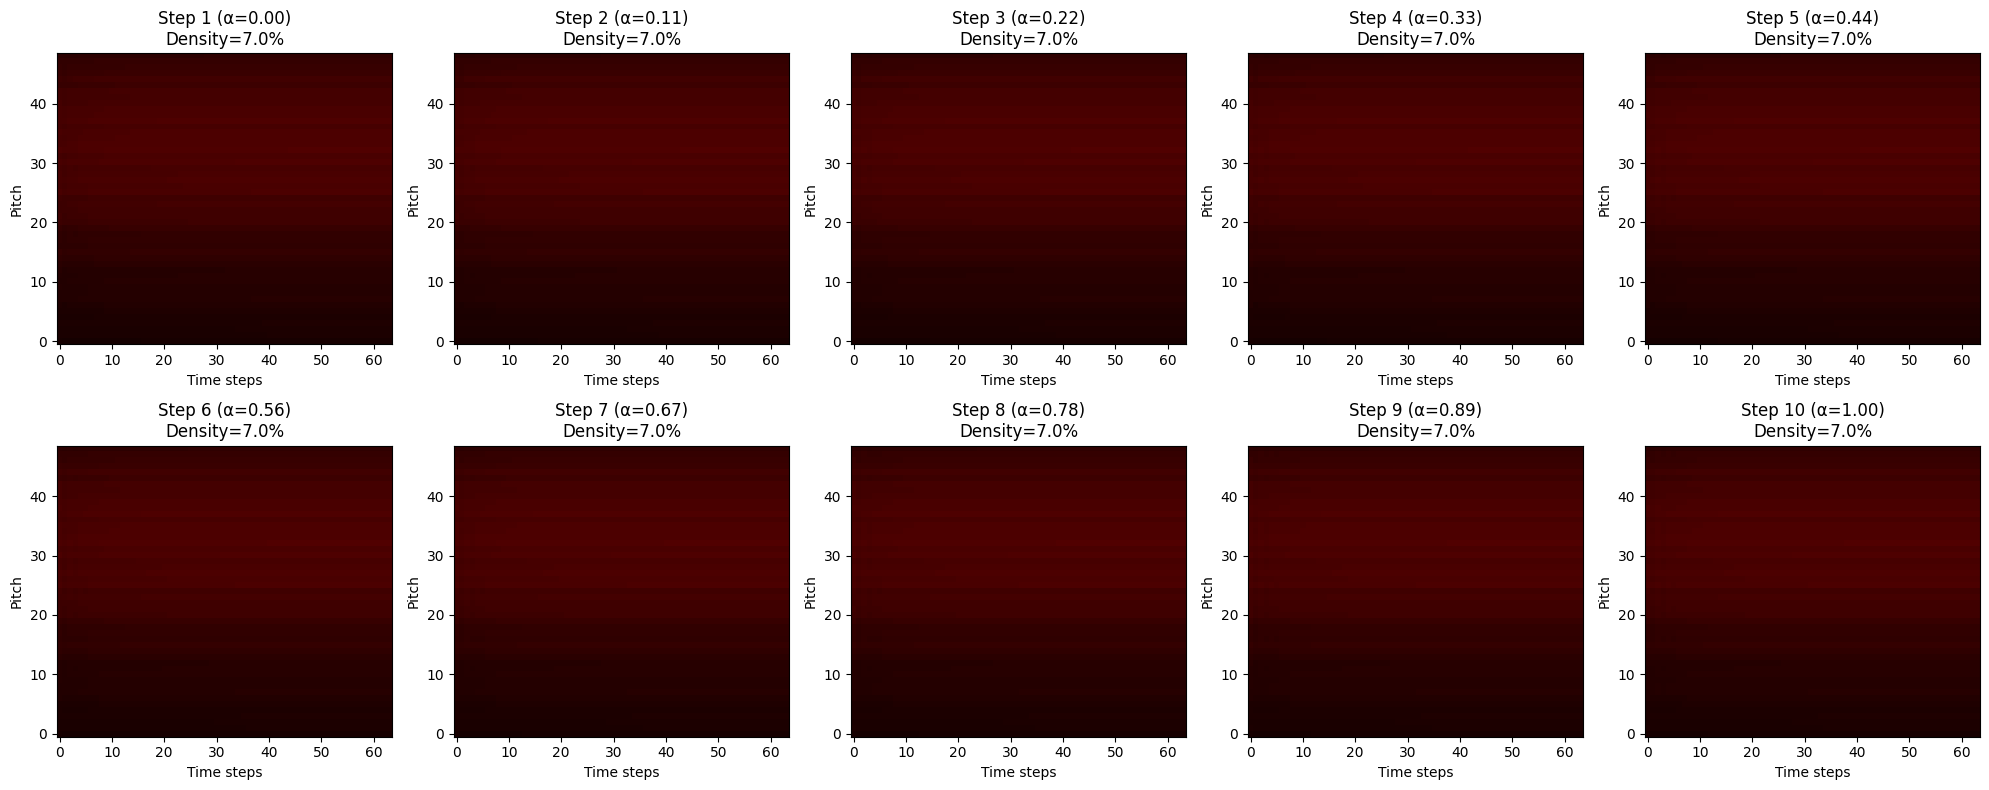

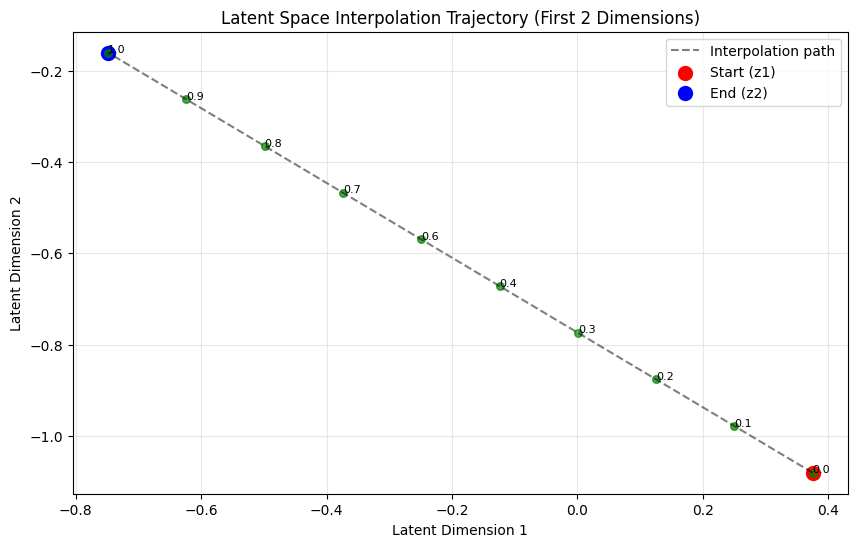


Latent interpolation experiment complete!
Listen to the MIDI files in order to hear smooth transitions between musical styles.


In [ ]:
# Cell 7: Latent Interpolation Experiment for Task 2 VAE
from generation.midi_export import numpy_to_midi

# Load the trained VAE model
checkpoint = torch.load('../outputs/models/vae_maestro.pth', map_location='cpu')

# Get latent dimension from saved model
latent_dim = checkpoint['model_state_dict']['decoder.fc_hidden.weight'].shape[1]
print(f"Loaded VAE model from epoch {checkpoint['epoch']}")
print(f"Validation loss: {checkpoint['val_loss']:.6f}")
print(f"Latent dimension: {latent_dim}")

# Recreate model with EXACT architecture that was trained
from models.vae import VAE

model = VAE(
    input_dim=49,
    hidden_dim=128,      # Match trained model
    latent_dim=latent_dim,
    seq_len=128,
    num_layers=1         # Match trained model
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully")

# Sample two random latent vectors
z1 = torch.randn(1, latent_dim)
z2 = torch.randn(1, latent_dim)

print(f"\nz1 mean: {z1.mean():.4f}, std: {z1.std():.4f}")
print(f"z2 mean: {z2.mean():.4f}, std: {z2.std():.4f}")

# Create interpolation steps
num_steps = 10
alphas = np.linspace(0, 1, num_steps)

output_dir = '../outputs/generated_midis/task2_interpolations/'
os.makedirs(output_dir, exist_ok=True)

interpolated_samples = []

print(f"\nGenerating {num_steps} interpolation steps...")
with torch.no_grad():
    for i, alpha in enumerate(alphas):
        # Linear interpolation between z1 and z2
        z_interp = (1 - alpha) * z1 + alpha * z2
        
        # Decode to piano roll
        generated = model.decoder(z_interp)
        generated = generated.squeeze().cpu().numpy()
        
        # Clip values to [0, 1]
        generated = np.clip(generated, 0, 1)
        
        interpolated_samples.append(generated)
        
        # Save as MIDI
        output_path = os.path.join(output_dir, f'interpolation_step_{i+1:03d}.mid')
        numpy_to_midi(generated, output_path, tempo=120, velocity_scale=100)
        
        # Save as numpy for visualization
        np.save(os.path.join(output_dir, f'interpolation_step_{i+1:03d}.npy'), generated)
        
        density = generated.mean() * 100
        print(f"Step {i+1:2d}/{num_steps} (alpha={alpha:.2f}): density={density:.1f}%")

print(f"\nInterpolation completed. Files saved to {output_dir}")

# Visualize the interpolation
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, sample in enumerate(interpolated_samples):
    # Show only first 64 steps for clarity
    display_sample = sample[:64]
    axes[i].imshow(display_sample.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    axes[i].set_title(f'Step {i+1} (α={alphas[i]:.2f})\nDensity={sample.mean()*100:.1f}%')
    axes[i].set_xlabel('Time steps')
    axes[i].set_ylabel('Pitch')

plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/vae_interpolation_visualization.png', dpi=150)
plt.show()

# Also plot the trajectory in latent space
plt.figure(figsize=(10, 6))
# Use first 2 dimensions for visualization
z1_2d = z1[0, :2].numpy()
z2_2d = z2[0, :2].numpy()
interp_2d = [( (1-alpha)*z1[0, :2] + alpha*z2[0, :2] ).numpy() for alpha in alphas]

plt.plot([z1_2d[0], z2_2d[0]], [z1_2d[1], z2_2d[1]], 'k--', alpha=0.5, label='Interpolation path')
plt.scatter(z1_2d[0], z1_2d[1], c='red', s=100, label='Start (z1)', marker='o')
plt.scatter(z2_2d[0], z2_2d[1], c='blue', s=100, label='End (z2)', marker='o')

for i, (x, y) in enumerate(interp_2d):
    plt.scatter(x, y, c='green', s=30, alpha=0.7)
    plt.annotate(f'{alphas[i]:.1f}', (x, y), fontsize=8)

plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Interpolation Trajectory (First 2 Dimensions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/vae_latent_trajectory.png', dpi=150)
plt.show()

print("\nLatent interpolation experiment complete!")
print("Listen to the MIDI files in order to hear smooth transitions between musical styles.")

Task 1 samples: 5
Task 2 samples: 8
Loaded human feedback from ../data/human_feedback/Task_1/feedback.xlsx
  Participants: 10
  Samples: 5
  Score range: 0.5 - 1.4
Loaded human feedback from ../data/human_feedback/Task_2/feedback.xlsx
  Participants: 10
  Samples: 8
  Score range: 3.4 - 4.2

METRIC COMPARISON: Task 1 (Autoencoder) vs Task 2 (VAE)
                    Metric Task 1 (Autoencoder) Task 2 (VAE)
          Rhythm Diversity                0.521        0.053
          Repetition Ratio                0.100        0.898
Pitch Histogram Similarity                0.803        0.732
         Human Score (1-5)                 0.97         3.87


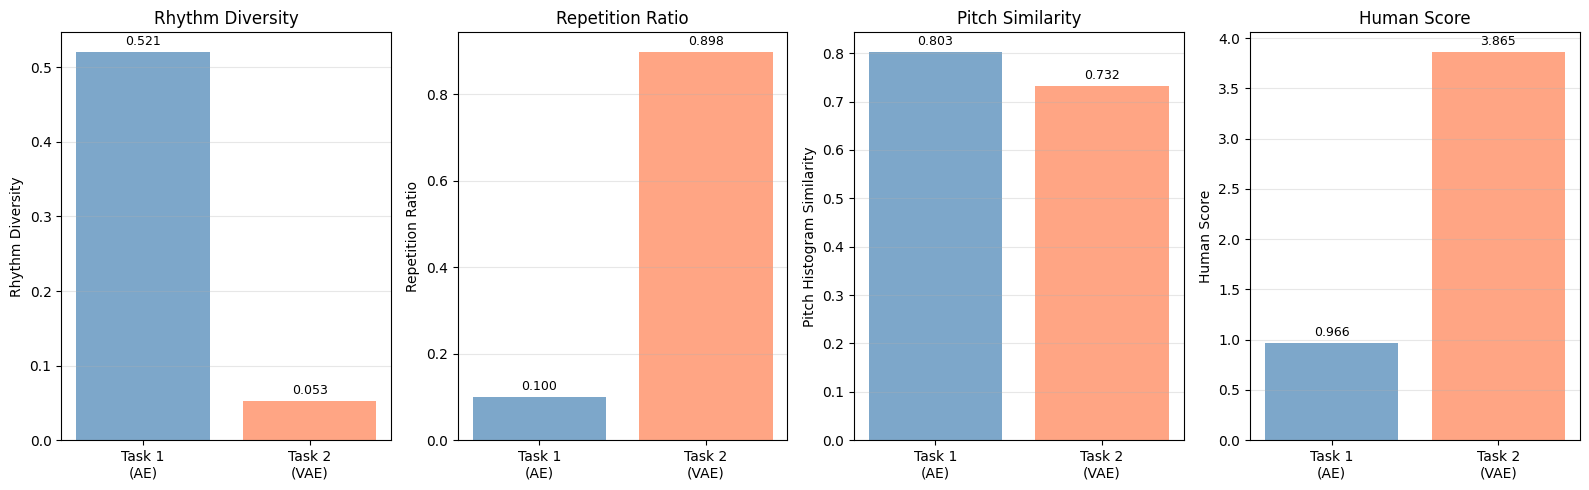


INTERPRETATION
✓ Task 2 (VAE) has higher human score - listeners prefer its samples
✓ Task 1 has higher rhythm diversity - more varied note durations
✓ Task 1 is less repetitive - fewer repeated patterns

Note: VAE posterior collapse may explain lower performance on some metrics.


: 

In [ ]:
# Cell 8: Compare Task 1 vs Task 2 Metrics
import sys
sys.path.append('../src')
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
from evaluation.metrics import compute_all_metrics, print_metrics
from evaluation.human_score import load_human_scores, compute_human_score

def midi_to_piano_roll_for_metrics(midi_path, fs=8, min_pitch=36, max_pitch=84):
    """Convert MIDI file to piano roll for metric calculation"""
    pm = pretty_midi.PrettyMIDI(midi_path)
    
    if len(pm.instruments) == 0:
        return None
    
    piano_roll = pm.get_piano_roll(fs=fs)
    piano_roll = piano_roll[min_pitch:max_pitch+1]
    
    if piano_roll.max() > 0:
        piano_roll = piano_roll / piano_roll.max()
    
    piano_roll = piano_roll.T
    return piano_roll.astype(np.float32)

# Load Task 1 samples
task1_dir = '../outputs/generated_midis/task1_autoencoder/'
task1_samples = []
for i in range(1, 6):
    midi_path = os.path.join(task1_dir, f'task1_sample_{i}.mid')
    if os.path.exists(midi_path):
        piano_roll = midi_to_piano_roll_for_metrics(midi_path)
        if piano_roll is not None:
            task1_samples.append(piano_roll)

# Load Task 2 samples
task2_dir = '../outputs/generated_midis/task2_vae//'
task2_samples = []
for i in range(1, 9):
    midi_path = os.path.join(task2_dir, f'task2_sample_{i}.mid')
    if os.path.exists(midi_path):
        piano_roll = midi_to_piano_roll_for_metrics(midi_path)
        if piano_roll is not None:
            task2_samples.append(piano_roll)

print(f"Task 1 samples: {len(task1_samples)}")
print(f"Task 2 samples: {len(task2_samples)}")

# Load real samples for pitch histogram comparison
real_segments = np.load('../data/train_test_split/test.npy')
real_samples = list(real_segments[:100])

# Compute metrics for both tasks
task1_metrics = compute_all_metrics(task1_samples, real_samples)
task2_metrics = compute_all_metrics(task2_samples, real_samples)

# Load human scores
task1_feedback = '../data/human_feedback/Task_1/feedback.xlsx'
task2_feedback = '../data/human_feedback/Task_2/feedback.xlsx'

if os.path.exists(task1_feedback):
    df1 = load_human_scores(task1_feedback)
    task1_human = compute_human_score(df1)
    task1_metrics['human_score'] = task1_human['overall_score']
    task1_metrics['human_score_std'] = task1_human['overall_std']

if os.path.exists(task2_feedback):
    df2 = load_human_scores(task2_feedback)
    task2_human = compute_human_score(df2)
    task2_metrics['human_score'] = task2_human['overall_score']
    task2_metrics['human_score_std'] = task2_human['overall_std']

# Create comparison table
comparison_data = {
    'Metric': ['Rhythm Diversity', 'Repetition Ratio', 'Pitch Histogram Similarity', 'Human Score (1-5)'],
    'Task 1 (Autoencoder)': [
        f"{task1_metrics['rhythm_diversity']:.3f}",
        f"{task1_metrics['repetition_ratio']:.3f}",
        f"{task1_metrics.get('pitch_histogram_similarity', 'N/A'):.3f}",
        f"{task1_metrics.get('human_score', 'N/A'):.2f}"
    ],
    'Task 2 (VAE)': [
        f"{task2_metrics['rhythm_diversity']:.3f}",
        f"{task2_metrics['repetition_ratio']:.3f}",
        f"{task2_metrics.get('pitch_histogram_similarity', 'N/A'):.3f}",
        f"{task2_metrics.get('human_score', 'N/A'):.2f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("METRIC COMPARISON: Task 1 (Autoencoder) vs Task 2 (VAE)")
print("="*60)
print(df_comparison.to_string(index=False))

# Create bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics_to_plot = ['rhythm_diversity', 'repetition_ratio', 'pitch_histogram_similarity', 'human_score']
titles = ['Rhythm Diversity', 'Repetition Ratio', 'Pitch Similarity', 'Human Score']
higher_better = [True, False, False, True]  # For repetition ratio, lower is better

for idx, (metric, title, higher) in enumerate(zip(metrics_to_plot, titles, higher_better)):
    val1 = task1_metrics.get(metric, 0)
    val2 = task2_metrics.get(metric, 0)
    
    if val1 == 0 and val2 == 0:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(title)
        continue
    
    bars = axes[idx].bar(['Task 1\n(AE)', 'Task 2\n(VAE)'], [val1, val2], 
                         color=['steelblue', 'coral'], alpha=0.7)
    axes[idx].set_ylabel(metric.replace('_', ' ').title())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(val1, val2),
                       f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/task1_vs_task2_comparison.png', dpi=150)
plt.show()

# Summary interpretation
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

if task1_metrics.get('human_score', 0) > task2_metrics.get('human_score', 0):
    print("✓ Task 1 (Autoencoder) has higher human score - listeners prefer its samples")
else:
    print("✓ Task 2 (VAE) has higher human score - listeners prefer its samples")

if task1_metrics['rhythm_diversity'] > task2_metrics['rhythm_diversity']:
    print("✓ Task 1 has higher rhythm diversity - more varied note durations")
else:
    print("✓ Task 2 has higher rhythm diversity - more varied note durations")

if task1_metrics['repetition_ratio'] < task2_metrics['repetition_ratio']:
    print("✓ Task 1 is less repetitive - fewer repeated patterns")
else:
    print("✓ Task 2 is less repetitive - fewer repeated patterns")

print("\nNote: VAE posterior collapse may explain lower performance on some metrics.")

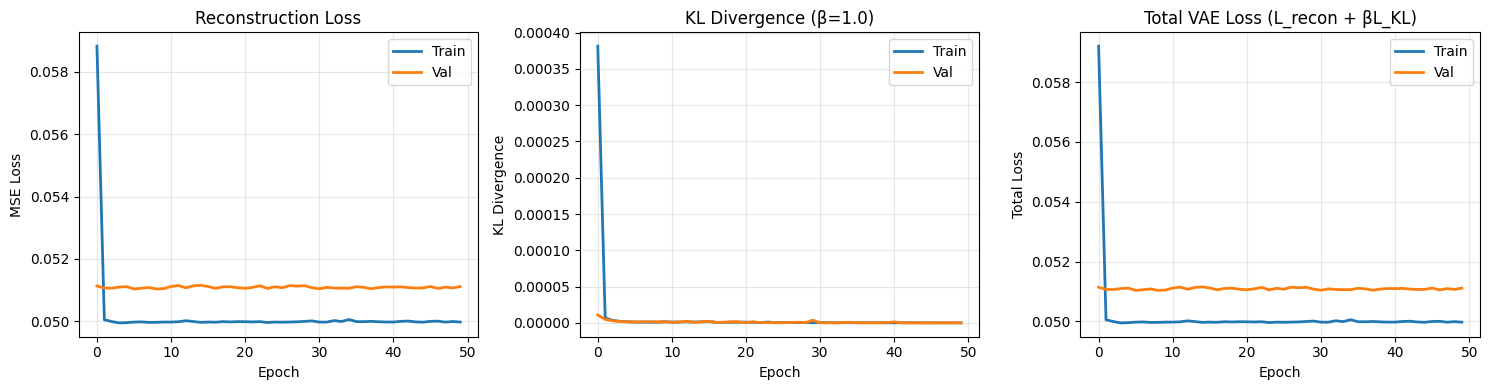

Loss curves saved to: ../outputs/plots/vae_loss_curve.png


In [ ]:
# Cell 9: Plot loss curves
trainer.plot_losses()

In [ ]:
# Cell 10: Test evaluation
test_recon, test_kl, test_total = trainer.validate(test_loader)
print(f"Test Results:")
print(f"  Reconstruction Loss: {test_recon:.6f}")
print(f"  KL Divergence: {test_kl:.6f}")
print(f"  Total VAE Loss: {test_total:.6f}")

Test Results:
  Reconstruction Loss: 0.050196
  KL Divergence: -0.000000
  Total VAE Loss: 0.050196
